In [1]:
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from langgraph.graph import add_messages
from typing import Annotated
from typing_extensions import TypedDict
import os
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [6]:
llm = ChatGroq(model="llama-3.3-70b-versatile")


def Superbot(state:State):
   return {"messages":[llm.invoke(state['messages'])]}

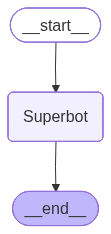

In [7]:
graph = StateGraph(State)

graph.add_node("Superbot",Superbot)
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
graph_builder.invoke({"messages":"Explain about LLM"})

{'messages': [HumanMessage(content='Explain about LLM', additional_kwargs={}, response_metadata={}, id='52948ef5-b5fd-461a-b976-fb7cb179a67a'),
  AIMessage(content="LLM stands for Large Language Model. It's a type of artificial intelligence (AI) designed to process and understand human language. LLMs are trained on vast amounts of text data, which enables them to learn patterns, relationships, and structures of language.\n\n**Key Characteristics of LLMs:**\n\n1. **Scale**: LLMs are trained on massive datasets, often consisting of billions of words or more. This scale allows them to capture nuances and complexities of language.\n2. **Depth**: LLMs have multiple layers of neural networks, which enable them to learn hierarchical representations of language, from simple words to complex sentences and contexts.\n3. **Language Understanding**: LLMs are designed to comprehend language, including syntax, semantics, and pragmatics. They can identify entities, relationships, and intent behind te